INSTALL LIBRARIES

In [1]:
!pip install pandas numpy matplotlib

IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

plt.style.use('ggplot')

CREATE MEMORY CLASS

In [3]:
class Memory:

    def __init__(self, text, importance):

        self.text = text

        self.importance = importance

        self.created = datetime.now()

        self.last_access = self.created

        self.access_count = 0

        self.strength = 1.0

        self.compressed = False

    def access(self):

        self.last_access = datetime.now()

        self.access_count += 1

        self.strength += 0.15

LONG TERM MEMORY STORE

In [4]:
class MemoryStore:

    def __init__(self):

        self.memories = []

    def add(self, text, importance):

        self.memories.append(Memory(text, importance))

    def show(self):

        for m in self.memories:

            print(m.text)

            print("Importance:",m.importance)

            print("Strength:",round(m.strength,2))

            print("Access:",m.access_count)

            print("-"*40)

ADDITION OF SAMPLE MEMORIES

In [5]:
store = MemoryStore()

store.add("User likes coffee",0.95)

store.add("Meeting at 3 PM",0.60)

store.add("Weather is sunny",0.25)

store.add("Python project deadline",0.90)

store.add("Favorite movie is Interstellar",0.80)

store.show()

User likes coffee
Importance: 0.95
Strength: 1.0
Access: 0
----------------------------------------
Meeting at 3 PM
Importance: 0.6
Strength: 1.0
Access: 0
----------------------------------------
Weather is sunny
Importance: 0.25
Strength: 1.0
Access: 0
----------------------------------------
Python project deadline
Importance: 0.9
Strength: 1.0
Access: 0
----------------------------------------
Favorite movie is Interstellar
Importance: 0.8
Strength: 1.0
Access: 0
----------------------------------------


MEMORY DECAY FUNCTION

In [6]:
def decay(memory, days):

    decay_rate = 0.12

    score = np.exp(-decay_rate*days)

    score *= memory.importance

    score *= (1+0.05*memory.access_count)

    memory.strength = score

SIMULATE PASSAGE OF TIME

In [7]:
days = np.arange(0,31)

history = []

for d in days:

    values=[]

    for m in store.memories:

        decay(m,d)

        values.append(m.strength)

    history.append(values)

history=np.array(history)

PLOT MEMORY DECAY CURVES

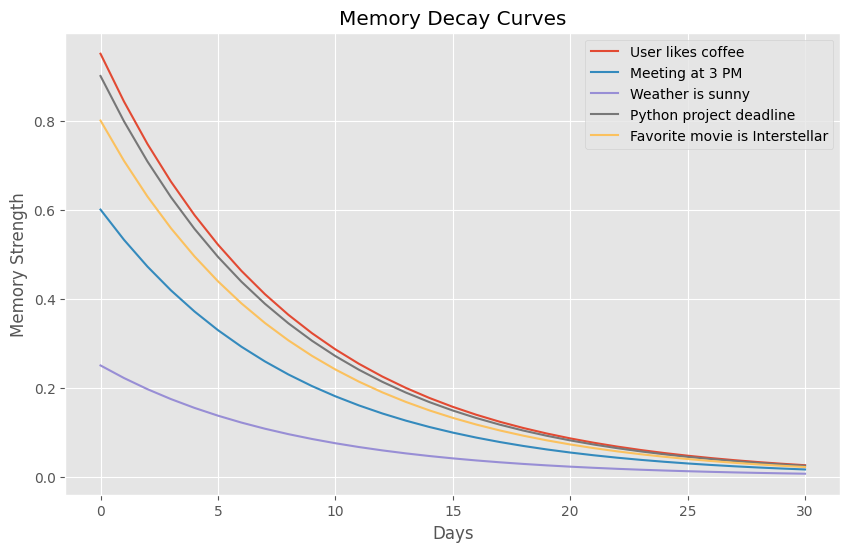

In [8]:
plt.figure(figsize=(10,6))

for i,m in enumerate(store.memories):

    plt.plot(days,history[:,i],label=m.text)

plt.xlabel("Days")

plt.ylabel("Memory Strength")

plt.title("Memory Decay Curves")

plt.legend()

plt.show()

IMPORTANCE BASED ON FORGETTING

In [9]:
threshold = 0.20

remaining=[]

forgotten=[]

for m in store.memories:

    if m.strength>threshold:

        remaining.append(m)

    else:

        forgotten.append(m)

print("Remaining:",len(remaining))

print("Forgotten:",len(forgotten))

Remaining: 0
Forgotten: 5


MEMORY COMPRESSION

In [10]:
for m in remaining:

    if len(m.text)>25:

        words=m.text.split()

        m.text=" ".join(words[:4])+"..."

        m.compressed=True

print("Compressed Memories")

for m in remaining:

    print(m.text,m.compressed)

Compressed Memories


RETRIEVAL FUNCTION

In [13]:
def retrieve(query):

    if len(remaining) == 0:
        return "No memories available."

    scores = []

    for m in remaining:

        overlap = len(
            set(query.lower().split()) &
            set(m.text.lower().split())
        )

        score = overlap * m.strength
        scores.append(score)

    if len(scores) == 0:
        return "No matching memory."

    if max(scores) == 0:
        return "No matching memory."

    idx = np.argmax(scores)

    remaining[idx].access()

    return remaining[idx].text

TEST RETRIEVAL

In [14]:
print(retrieve("coffee"))

print(retrieve("deadline"))

print(retrieve("movie"))

No memories available.
No memories available.
No memories available.


SIMULATE MULTI-WEEK TASKS

In [15]:
weeks=8

recall=[]

storage=[]

for w in range(weeks):

    day=w*7

    alive=0

    total_strength=0

    for m in store.memories:

        decay(m,day)

        if m.strength>threshold:

            alive+=1

            total_strength+=m.strength

    recall.append(total_strength/len(store.memories))

    storage.append(alive)

RECALL ACCURACY PLOT

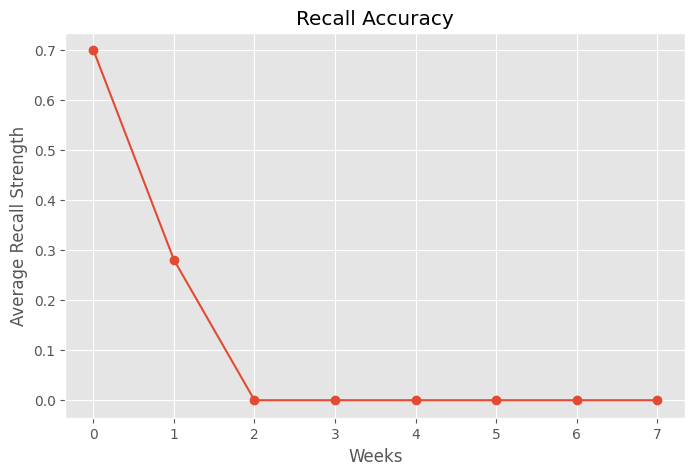

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(weeks),recall,marker='o')

plt.xlabel("Weeks")

plt.ylabel("Average Recall Strength")

plt.title("Recall Accuracy")

plt.show()

STORAGE EFFICIENCY

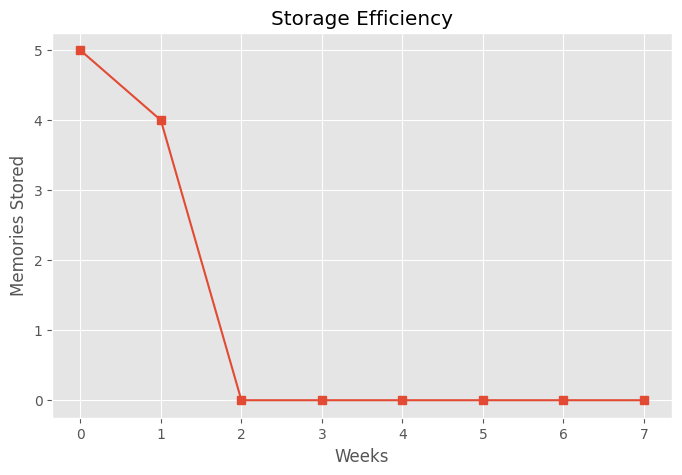

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(weeks),storage,marker='s')

plt.xlabel("Weeks")

plt.ylabel("Memories Stored")

plt.title("Storage Efficiency")

plt.show()

HALLUCINATION REDUCTION SIMULATION

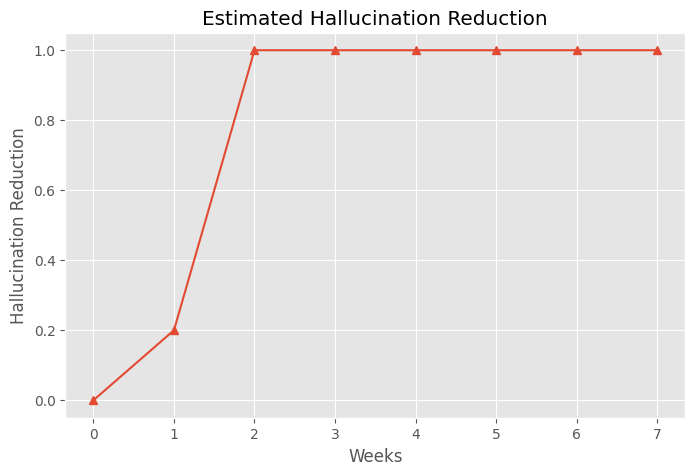

In [18]:
hallucination=[]

for s in storage:

    rate=1-(s/len(store.memories))

    hallucination.append(rate)

plt.figure(figsize=(8,5))

plt.plot(range(weeks),hallucination,marker='^')

plt.xlabel("Weeks")

plt.ylabel("Hallucination Reduction")

plt.title("Estimated Hallucination Reduction")

plt.show()

EVALUATION TABLE

In [19]:
results=pd.DataFrame({

    "Week":range(weeks),

    "Recall Accuracy":recall,

    "Storage":storage,

    "Hallucination Reduction":hallucination

})

results

,Week,Recall Accuracy,Storage,Hallucination Reduction
0,0,0.700000,5,0.0
1,1,0.280612,4,0.2
2,2,0.000000,0,1.0
3,3,0.000000,0,1.0
4,4,0.000000,0,1.0
5,5,0.000000,0,1.0
6,6,0.000000,0,1.0
7,7,0.000000,0,1.0


SAVE RESULTS

In [20]:
results.to_csv("memory_decay_results.csv",index=False)

print("Saved.")

Saved.
